In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\jiyad\\OneDrive\\Documents\\Desktop\\Dataset for ML\\wine_data.csv")

In [3]:
df

,class_label,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,OD280/OD315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [4]:
df = df.drop(['ash', 'alcalinity_of_ash',
       'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'OD280/OD315_of_diluted_wines', 'proline'], axis = 1)

In [5]:
df.columns

Index(['class_label', 'alcohol', 'malic_acid'], dtype='object')

In [6]:
df

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='alcohol', ylabel='Density'>

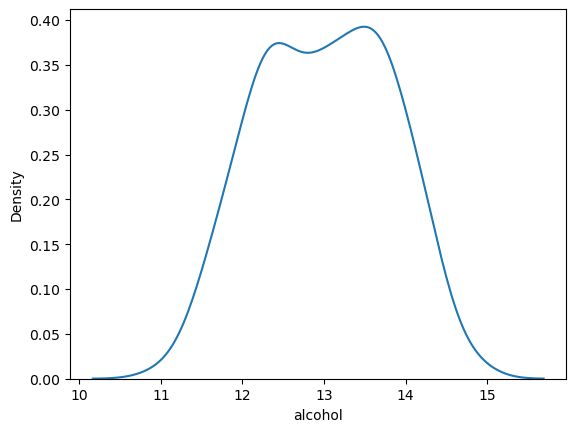

In [7]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='malic_acid', ylabel='Density'>

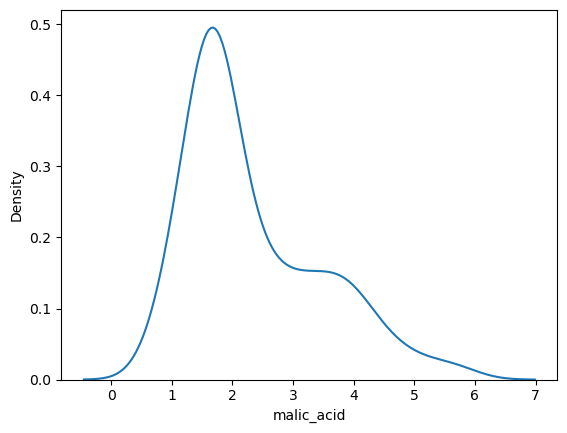

In [8]:
sns.kdeplot(df['malic_acid'])

# Scatter Plot Between 2 columns 

<Axes: xlabel='alcohol', ylabel='malic_acid'>

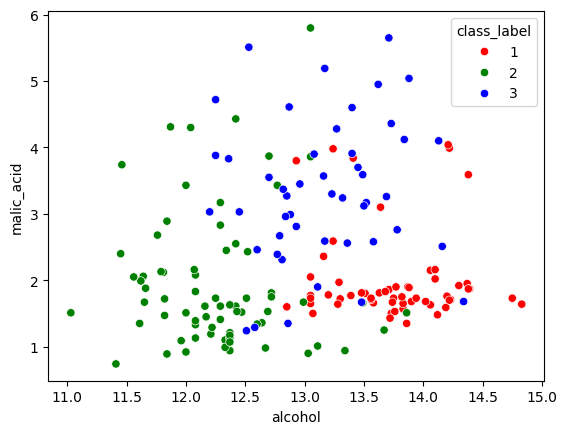

In [9]:
color_dict = {1: 'red', 2: 'green', 3: 'blue'}

sns.scatterplot(
    data=df,
    x='alcohol',
    y='malic_acid',
    hue='class_label',
    palette=color_dict
)

# Train_Test_Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df[['alcohol', 'malic_acid']], df['class_label'], test_size = 0.2, random_state = 0)

In [11]:
X_train

,alcohol,malic_acid
161,13.69,3.26
92,12.69,1.53
94,11.62,1.99
174,13.40,3.91
24,13.50,1.81
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [12]:
X_test.shape, X_train.shape

((36, 2), (142, 2))

# Min_Max_Scaler

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fir the scaler to th etrian set , it will learn the parameter
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled

array([[0.71505376, 0.51323829],
       [0.44623656, 0.16089613],
       [0.15860215, 0.25458248],
       [0.63709677, 0.64562118],
       [0.66397849, 0.21792261],
       [0.72580645, 0.15478615],
       [0.33870968, 0.42566191],
       [0.42204301, 0.12219959],
       [0.10215054, 0.        ],
       [0.7016129 , 0.48065173],
       [0.42204301, 0.3503055 ],
       [0.25      , 0.0712831 ],
       [0.32795699, 0.6395112 ],
       [0.87903226, 0.24032587],
       [0.49731183, 0.45824847],
       [0.66129032, 0.58044807],
       [0.68010753, 0.19755601],
       [0.88978495, 0.19144603],
       [0.72043011, 0.22810591],
       [0.31989247, 0.11201629],
       [0.60215054, 0.7209776 ],
       [0.57258065, 0.57637475],
       [0.76075269, 0.15682281],
       [0.48924731, 0.51527495],
       [0.75537634, 0.68839104],
       [0.61021505, 0.19959267],
       [0.54301075, 0.63543788],
       [0.39784946, 0.10183299],
       [0.33870968, 0.13645621],
       [0.46774194, 0.54786151],
       [0.

In [15]:
X_train_scaled  = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [16]:
X_train_scaled

,alcohol,malic_acid
0,0.715054,0.513238
1,0.446237,0.160896
2,0.158602,0.254582
3,0.637097,0.645621
4,0.663978,0.217923
...,...,...
137,0.212366,0.199593
138,0.360215,0.087576
139,0.373656,0.177189
140,0.771505,0.191446


In [17]:
np.round(X_train.describe(), 1)

,alcohol,malic_acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [18]:
np.round(X_train_scaled.describe(), 1)

,alcohol,malic_acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


#  Scatter Plot

<function matplotlib.pyplot.show(close=None, block=None)>

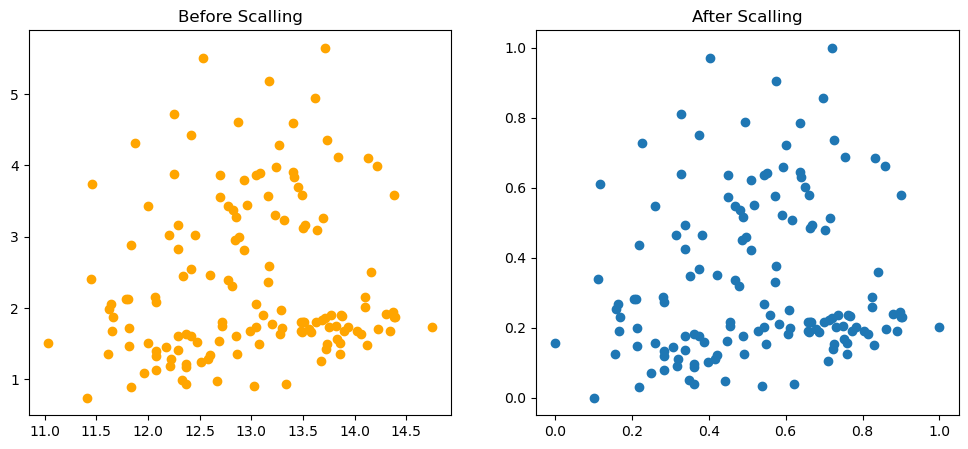

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(X_train['alcohol'], X_train['malic_acid'], color  = "orange")
ax1.set_title("Before Scalling")

ax2.scatter(X_train_scaled['alcohol'], X_train_scaled['malic_acid'])
ax2.set_title("After Scalling")
plt.show

# Kde_plot

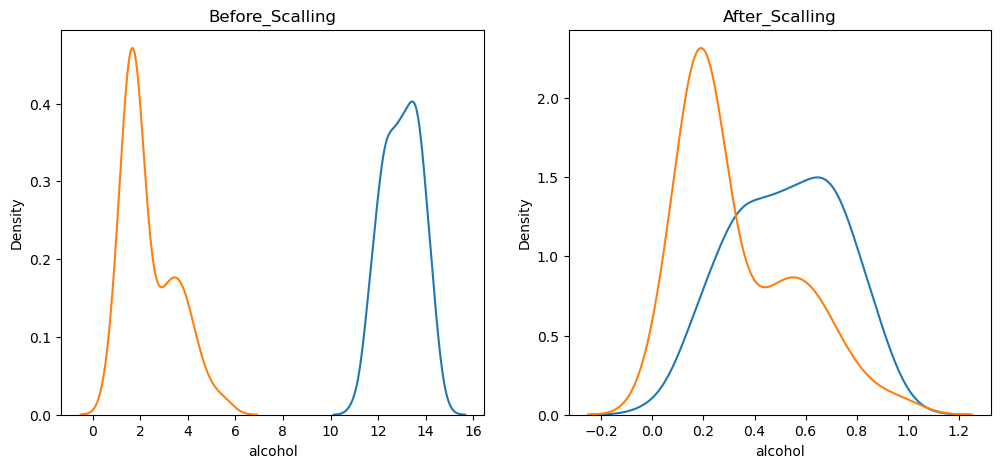

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

#before scalling
ax1.set_title("Before_Scalling")
sns.kdeplot(X_train['alcohol'], ax = ax1)
sns.kdeplot(X_train['malic_acid'], ax = ax1)

#after scalling
ax2.set_title("After_Scalling")
sns.kdeplot(X_train_scaled['alcohol'], ax = ax2)
sns.kdeplot(X_train_scaled['malic_acid'], ax = ax2)
plt.show()

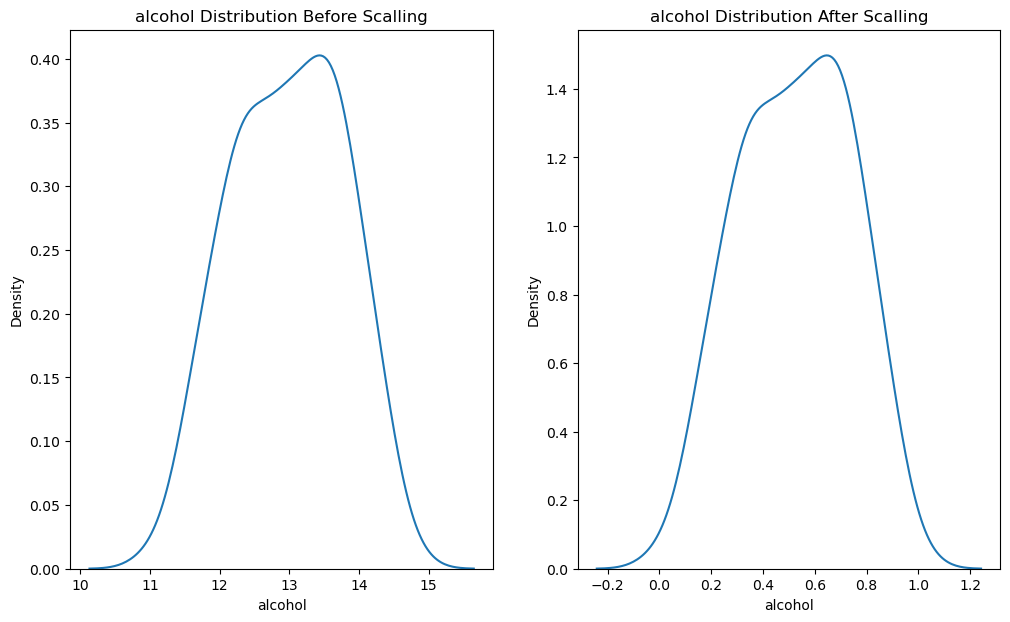

In [23]:
# Comparition of Distribution

fig, (ax1, ax2)= plt.subplots(ncols  = 2, figsize = (12, 7))

#before scalling
ax1.set_title("alcohol Distribution Before Scalling")
sns.kdeplot(X_train['alcohol'], ax = ax1)

# after scalling
ax2.set_title("alcohol Distribution After Scalling")
sns.kdeplot(X_train_scaled['alcohol'], ax = ax2)
plt.show()

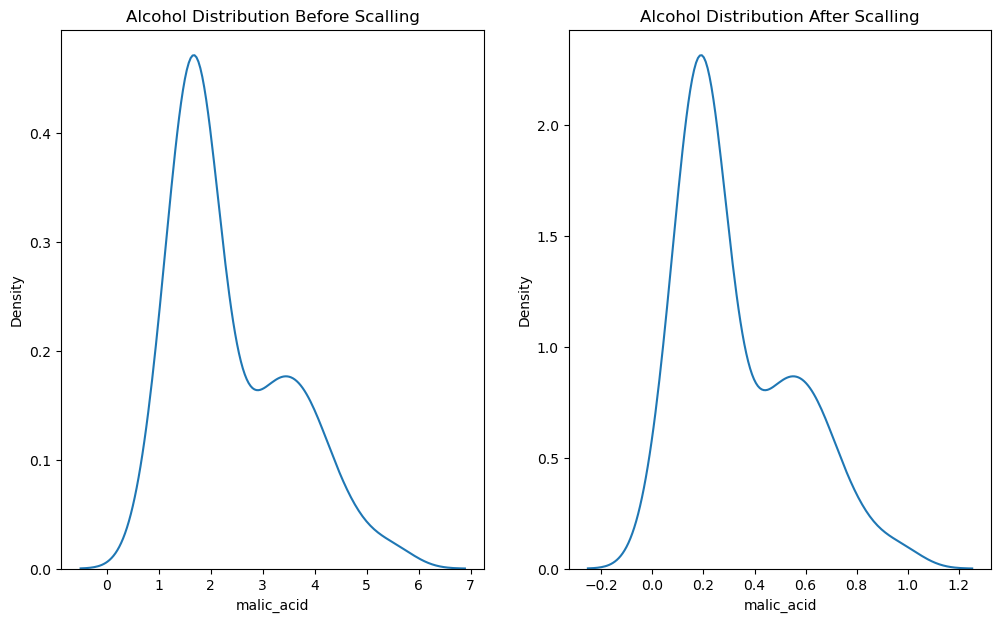

In [24]:
fig, (ax1, ax2)= plt.subplots(ncols  = 2, figsize = (12, 7))

#before scalling
ax1.set_title("Alcohol Distribution Before Scalling")
sns.kdeplot(X_train['malic_acid'], ax = ax1)

# after scalling
ax2.set_title("Alcohol Distribution After Scalling")
sns.kdeplot(X_train_scaled['malic_acid'], ax = ax2)
plt.show()